# **Dataset: RAFDB**

In [ ]:
# For Colab: Mount Google Drive or upload dataset to /content
!unzip -q "/content/RAF-DB.zip" -d "/content"
data_dir = "/content/fer2013"

In [ ]:
import os
import numpy as np # linear algebra
import pandas as pd # data processing,


In [ ]:
train_dir = '/content/DATASET/train'
test_dir = '/content/DATASET/test'

In [ ]:
num_train_folders = len([folder for folder in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, folder))])
num_test_folders = len([folder for folder in os.listdir(test_dir) if os.path.isdir(os.path.join(test_dir, folder))])

print(f"Number of folders (classes) in the train directory: {num_train_folders}")
print(f"Number of folders (classes) in the test directory: {num_test_folders}")

Number of folders (classes) in the train directory: 7
Number of folders (classes) in the test directory: 7


In [ ]:
def get_subfolders_and_image_counts(directory):
    subfolders = {}
    for subdir, dirs, files in os.walk(directory):
        if dirs:
            for folder in dirs:
                folder_path = os.path.join(subdir, folder)
                num_images = len([file for file in os.listdir(folder_path) if file.endswith(('.png', '.jpg', '.jpeg'))])
                subfolders[folder] = num_images
    return subfolders

train_subfolders = get_subfolders_and_image_counts(train_dir)
test_subfolders = get_subfolders_and_image_counts(test_dir)

In [ ]:
class_mapping = {
    '1': 'Surprise',
    '2': 'Fear',
    '3': 'Disgust',
    '4': 'Happiness',
    '5': 'Sadness',
    '6': 'Anger',
    '7': 'Neutral'
}


In [ ]:
print("Training Subfolders and Image Counts:")
for folder, count in train_subfolders.items():
    print(f"{class_mapping[folder]} ({folder}): {count} images")

print("\nTest Subfolders and Image Counts:")
for folder, count in test_subfolders.items():
    print(f"{class_mapping[folder]} ({folder}): {count} images")


Training Subfolders and Image Counts:
Surprise (1): 1290 images
Disgust (3): 717 images
Neutral (7): 2524 images
Sadness (5): 1982 images
Fear (2): 281 images
Happiness (4): 4772 images
Anger (6): 705 images

Test Subfolders and Image Counts:
Surprise (1): 329 images
Disgust (3): 160 images
Neutral (7): 680 images
Sadness (5): 478 images
Fear (2): 74 images
Happiness (4): 1185 images
Anger (6): 162 images


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import pandas as pd

data = {
    'Category': [
        'Surprise', 'Fear', 'Disgust', 'Happiness', 'Sadness', 'Anger', 'Neutral',
        'Surprise', 'Fear', 'Disgust', 'Happiness', 'Sadness', 'Anger', 'Neutral'
    ],
    'Count': [
        1290, 281, 717, 4772, 1982, 705, 2524,  # Training
        329, 74, 160, 1185, 478, 162, 680       # Test
    ],
    'Dataset': ['Training'] * 7 + ['Test'] * 7
}

df = pd.DataFrame(data)


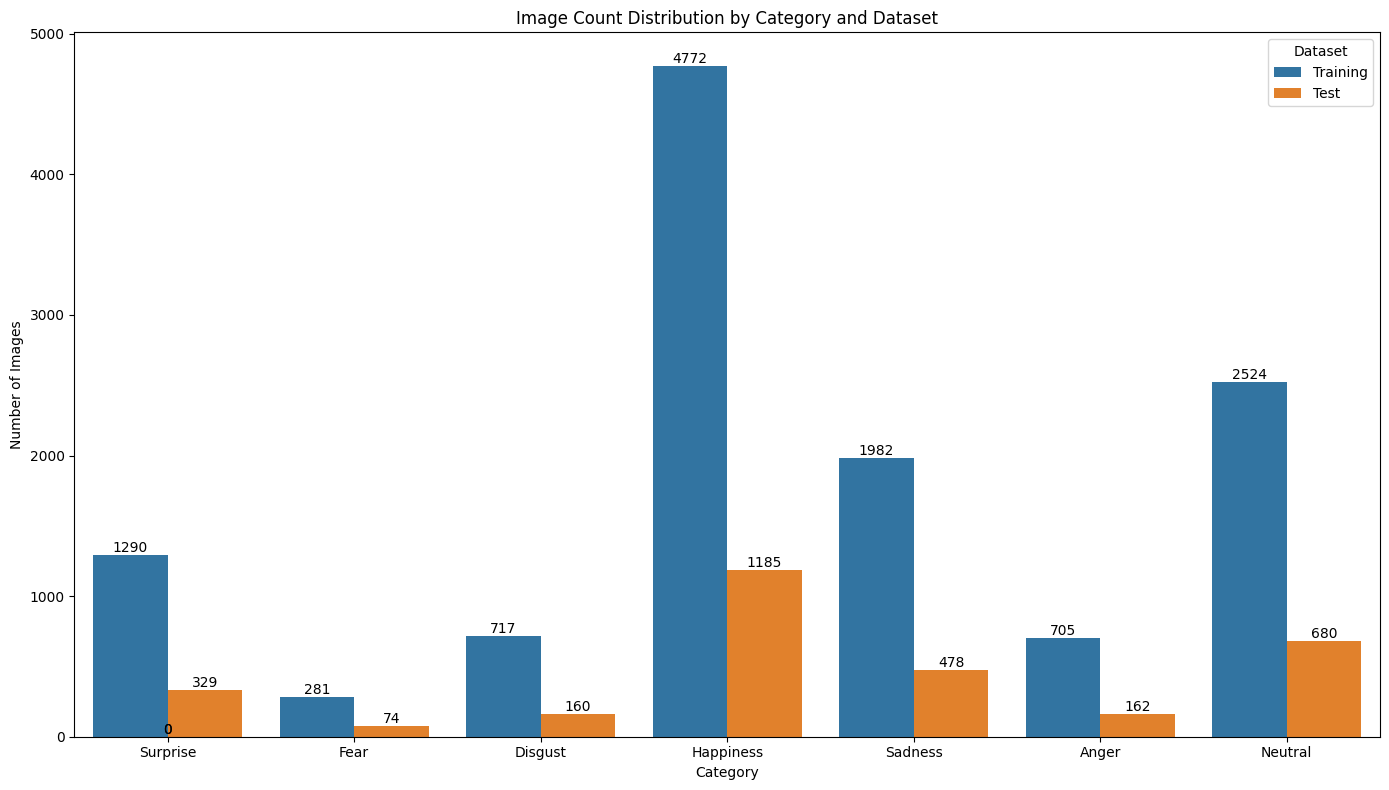

In [ ]:
plt.figure(figsize=(14, 8))

ax = sns.barplot(x='Category', y='Count', hue='Dataset', data=df)

for p in ax.patches:
    width = p.get_width()
    height = p.get_height()
    x = p.get_x() + width / 2
    y = p.get_y() + height
    ax.annotate(f'{int(height)}', (x, y), ha='center', va='bottom', fontsize=10)

plt.title('Image Count Distribution by Category and Dataset')
plt.xlabel('Category')
plt.ylabel('Number of Images')
plt.legend(title='Dataset')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Corrected training set counts
train_counts = {
    'Category': ['Surprise', 'Fear', 'Disgust', 'Happiness', 'Sadness', 'Anger', 'Neutral'],
    'Count': [1290, 281, 717, 4772, 1982, 705, 2524]
}

# Corrected test set counts
test_counts = {
    'Category': ['Surprise', 'Fear', 'Disgust', 'Happiness', 'Sadness', 'Anger', 'Neutral'],
    'Count': [329, 74, 160, 1185, 478, 162, 680]
}

df_train = pd.DataFrame(train_counts)
df_test = pd.DataFrame(test_counts)


In [ ]:
total_train = df_train['Count'].sum()
total_test = df_test['Count'].sum()

In [ ]:
df_train['Percentage'] = (df_train['Count'] / total_train) * 100
df_test['Percentage'] = (df_test['Count'] / total_test) * 100

print("Training Dataset Percentages:")
for _, row in df_train.iterrows():
    print(f"{row['Category'].capitalize()}: {row['Percentage']:.2f}%")

print("\nTest Dataset Percentages:")
for _, row in df_test.iterrows():
    print(f"{row['Category'].capitalize()}: {row['Percentage']:.2f}%")

Training Dataset Percentages:
Surprise: 10.51%
Fear: 2.29%
Disgust: 5.84%
Happiness: 38.89%
Sadness: 16.15%
Anger: 5.75%
Neutral: 20.57%

Test Dataset Percentages:
Surprise: 10.72%
Fear: 2.41%
Disgust: 5.22%
Happiness: 38.62%
Sadness: 15.58%
Anger: 5.28%
Neutral: 22.16%


In [ ]:
import cv2

In [ ]:
def display_images_from_folders(directory, title):

    folders = [folder for folder in os.listdir(directory) if os.path.isdir(os.path.join(directory, folder))]

    for folder in folders:
        folder_path = os.path.join(directory, folder)
        image_files = os.listdir(folder_path)[:5]

        fig, axes = plt.subplots(1, 5, figsize=(15, 5))
        fig.suptitle(f"{title} - Class: {folder}", fontsize=16)

        for i, image_file in enumerate(image_files):
            image_path = os.path.join(folder_path, image_file)
            image = cv2.imread(image_path)  # Read in color (BGR)
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert to RGB
            axes[i].imshow(image)
            axes[i].axis('off')
            axes[i].set_title(f"Image {i+1}")

        plt.show()


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
train_datagen = ImageDataGenerator(
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    rescale=1./255,
    validation_split=0.2
)

validation_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    directory=train_dir,
    target_size=(48, 48),
    batch_size=64,
    color_mode='grayscale',
    class_mode='categorical',
    subset='training'
)

validation_generator = validation_datagen.flow_from_directory(
    directory=test_dir,
    target_size=(48, 48),
    batch_size=64,
    color_mode='grayscale',
    class_mode='categorical',
    subset='validation'
)

class_names = list(train_generator.class_indices.keys())

Found 9819 images belonging to 7 classes.
Found 611 images belonging to 7 classes.


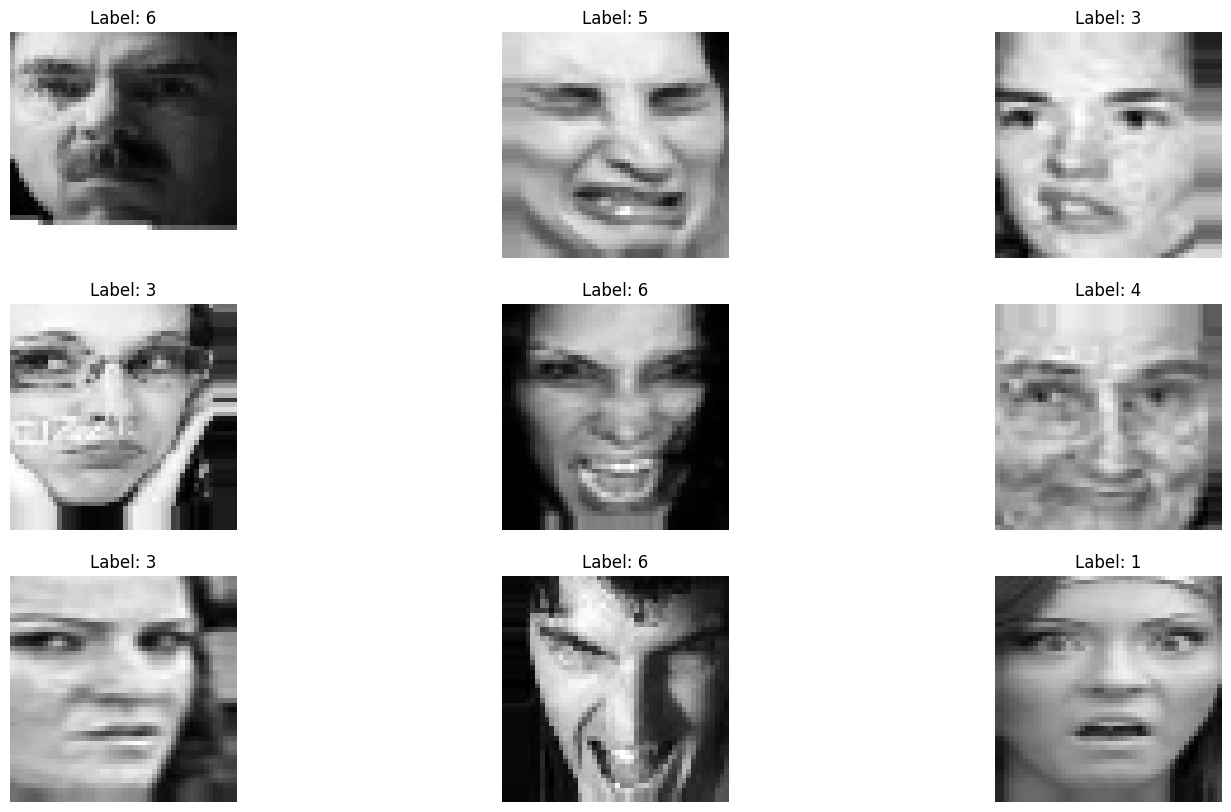

In [ ]:
def visualize_samples(generator):
    x_batch, y_batch = next(generator)
    plt.figure(figsize=(18, 10))
    for i in range(9):
        plt.subplot(3, 3, i+1)
        plt.imshow(x_batch[i].reshape(48, 48), cmap='gray')
        label_index = np.argmax(y_batch[i])
        plt.title(f"Label: {class_names[label_index]}")
        plt.axis('off')
    plt.show()

visualize_samples(train_generator)

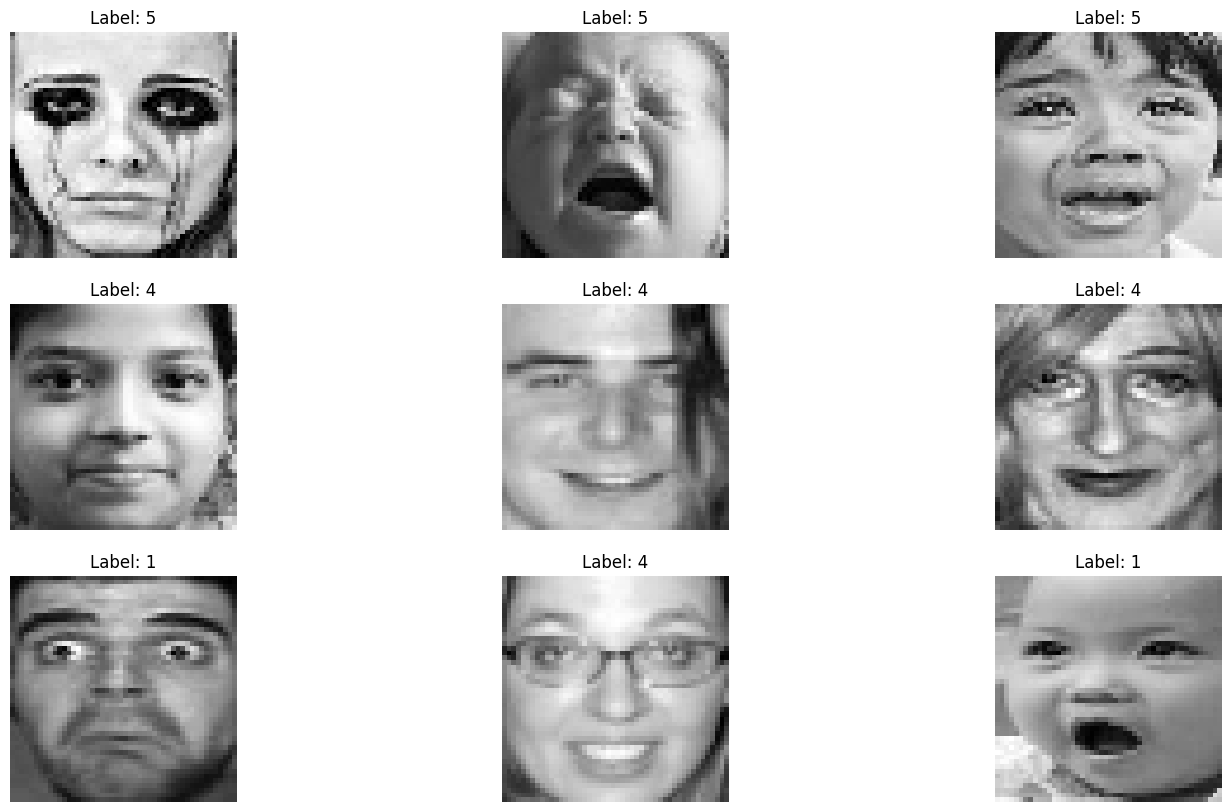

In [ ]:
visualize_samples(validation_generator)

In [ ]:
filepaths = []
labels = []

folds = os.listdir(train_dir)
for fold in folds:
    foldpath = os.path.join(train_dir, fold)
    filelist = os.listdir(foldpath)
    for file in filelist:
        fpath = os.path.join(foldpath, file)

        filepaths.append(fpath)
        labels.append(fold)

Fseries = pd.Series(filepaths, name= 'filepaths')
Lseries = pd.Series(labels, name='labels')
train_df = pd.concat([Fseries, Lseries], axis= 1)

In [ ]:
train_df

,filepaths,labels
0,/content/DATASET/train/1/train_02017_aligned.jpg,1
1,/content/DATASET/train/1/train_03557_aligned.jpg,1
2,/content/DATASET/train/1/train_04771_aligned.jpg,1
3,/content/DATASET/train/1/train_05955_aligned.jpg,1
4,/content/DATASET/train/1/train_06209_aligned.jpg,1
...,...,...
12266,/content/DATASET/train/6/train_05918_aligned.jpg,6
12267,/content/DATASET/train/6/train_07178_aligned.jpg,6
12268,/content/DATASET/train/6/train_06366_aligned.jpg,6
12269,/content/DATASET/train/6/train_09078_aligned.jpg,6


In [ ]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(train_df[['filepaths']], train_df['labels'])

balanced_train_df = pd.DataFrame({
    'filepaths': X_resampled['filepaths'],
    'labels': y_resampled
})


In [ ]:
balanced_train_df['labels'].unique()

array(['1', '3', '7', '5', '2', '4', '6'], dtype=object)

In [ ]:
balanced_train_df['labels'].value_counts()

,count
labels,
1,4772
3,4772
7,4772
5,4772
2,4772
4,4772
6,4772


In [ ]:
balanced_train_df

,filepaths,labels
0,/content/DATASET/train/1/train_02017_aligned.jpg,1
1,/content/DATASET/train/1/train_03557_aligned.jpg,1
2,/content/DATASET/train/1/train_04771_aligned.jpg,1
3,/content/DATASET/train/1/train_05955_aligned.jpg,1
4,/content/DATASET/train/1/train_06209_aligned.jpg,1
...,...,...
33399,/content/DATASET/train/7/train_11285_aligned.jpg,7
33400,/content/DATASET/train/7/train_12230_aligned.jpg,7
33401,/content/DATASET/train/7/train_10494_aligned.jpg,7
33402,/content/DATASET/train/7/train_09801_aligned.jpg,7


In [ ]:
filepaths = []
labels = []

folds = os.listdir(test_dir)
for fold in folds:
    foldpath = os.path.join(test_dir, fold)
    filelist = os.listdir(foldpath)
    for file in filelist:
        fpath = os.path.join(foldpath, file)

        filepaths.append(fpath)
        labels.append(fold)

Fseries = pd.Series(filepaths, name= 'filepaths')
Lseries = pd.Series(labels, name='labels')
ts_df = pd.concat([Fseries, Lseries], axis= 1)

In [ ]:
ts_df

,filepaths,labels
0,/content/DATASET/test/1/test_1210_aligned.jpg,1
1,/content/DATASET/test/1/test_1967_aligned.jpg,1
2,/content/DATASET/test/1/test_0102_aligned.jpg,1
3,/content/DATASET/test/1/test_0878_aligned.jpg,1
4,/content/DATASET/test/1/test_0675_aligned.jpg,1
...,...,...
3063,/content/DATASET/test/6/test_1760_aligned.jpg,6
3064,/content/DATASET/test/6/test_1838_aligned.jpg,6
3065,/content/DATASET/test/6/test_1301_aligned.jpg,6
3066,/content/DATASET/test/6/test_0321_aligned.jpg,6


In [ ]:
ts_df['labels'].unique()

array(['1', '3', '7', '5', '2', '4', '6'], dtype=object)

In [ ]:
ts_df['labels'].value_counts()

,count
labels,
4,1185
7,680
5,478
1,329
6,162
3,160
2,74


In [ ]:
ros = RandomOverSampler(random_state=42)
X_resampled_ts, y_resampled_ts = ros.fit_resample(ts_df[['filepaths']], ts_df['labels'])

balanced_ts_df = pd.DataFrame({
    'filepaths': X_resampled_ts['filepaths'],
    'labels': y_resampled_ts
})


In [ ]:
balanced_ts_df

,filepaths,labels
0,/content/DATASET/test/1/test_1210_aligned.jpg,1
1,/content/DATASET/test/1/test_1967_aligned.jpg,1
2,/content/DATASET/test/1/test_0102_aligned.jpg,1
3,/content/DATASET/test/1/test_0878_aligned.jpg,1
4,/content/DATASET/test/1/test_0675_aligned.jpg,1
...,...,...
8290,/content/DATASET/test/7/test_2998_aligned.jpg,7
8291,/content/DATASET/test/7/test_2981_aligned.jpg,7
8292,/content/DATASET/test/7/test_2635_aligned.jpg,7
8293,/content/DATASET/test/7/test_2716_aligned.jpg,7


In [ ]:
import time
import shutil
import pathlib
import itertools
from PIL import Image

import cv2
import seaborn as sns
sns.set_style('darkgrid')
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout, BatchNormalization
from tensorflow.keras import regularizers

import warnings
warnings.filterwarnings("ignore")

print ('check')

check


In [ ]:
valid_df, test_df = train_test_split(balanced_train_df,  train_size= 0.2, shuffle= True, random_state= 42)

In [ ]:
batch_size = 16
img_size = (224, 224)
channels = 1
img_shape = (img_size[0], img_size[1], channels)

tr_gen = ImageDataGenerator()
ts_gen = ImageDataGenerator()

train_gen = tr_gen.flow_from_dataframe(balanced_train_df, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode= 'sparse',
                                    color_mode= 'grayscale', shuffle= True, batch_size= batch_size)

valid_gen = ts_gen.flow_from_dataframe(valid_df, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode= 'sparse',
                                     color_mode= 'grayscale', shuffle= True, batch_size= batch_size)

test_gen = ts_gen.flow_from_dataframe(ts_df, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode= 'sparse',
                                    color_mode= 'grayscale', shuffle= False, batch_size= batch_size)

Found 33404 validated image filenames belonging to 7 classes.
Found 6680 validated image filenames belonging to 7 classes.
Found 3068 validated image filenames belonging to 7 classes.


In [ ]:
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

In [ ]:
train_df_new, temp_df_new = train_test_split(
    balanced_train_df,
    train_size=0.8,
    shuffle=True,
    random_state=42,
    stratify=balanced_train_df['labels']
)

valid_df_new, test_df_new = train_test_split(
    temp_df_new,
    test_size=0.5,
    shuffle=True,
    random_state=42,
    stratify=temp_df_new['labels']
)

In [ ]:
batch_size = 16
img_size = (224, 224)
channels = 1
img_shape = (img_size[0], img_size[1], channels)

tr_gen = ImageDataGenerator()
ts_gen = ImageDataGenerator()

train_gen_new = tr_gen.flow_from_dataframe(train_df_new, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode= 'sparse',
                                    color_mode= 'grayscale', shuffle= True, batch_size= batch_size)

valid_gen_new = ts_gen.flow_from_dataframe(valid_df_new, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode= 'sparse',
                                     color_mode= 'grayscale', shuffle= True, batch_size= batch_size)

test_gen_new = ts_gen.flow_from_dataframe(test_df_new, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode= 'sparse',
                                    color_mode= 'grayscale', shuffle= False, batch_size= batch_size)

Found 26723 validated image filenames belonging to 7 classes.
Found 3340 validated image filenames belonging to 7 classes.
Found 3341 validated image filenames belonging to 7 classes.


**Implemented a custom convolutional neural network (CNN) integrated with Squeeze-and-Excitation (SE) and Class Activation Mapping (CAM) modules to recognize facial emotions.**

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model

class SEBlock(layers.Layer):
    def __init__(self, channels, reduction_ratio=16):
        super(SEBlock, self).__init__()
        self.squeeze = layers.GlobalAveragePooling2D()
        self.fc1 = layers.Dense(channels // reduction_ratio, activation='relu')
        self.fc2 = layers.Dense(channels, activation='sigmoid')

    def call(self, inputs):
        se = self.squeeze(inputs)
        se = self.fc1(se)
        se = self.fc2(se)
        se = tf.reshape(se, [-1, 1, 1, tf.shape(inputs)[-1]])
        return inputs * se

class CAMBlock(layers.Layer):
    def __init__(self, channels, reduction_ratio=16):
        super(CAMBlock, self).__init__()
        self.channels = channels
        self.global_avg_pool = layers.GlobalAveragePooling2D()
        self.global_max_pool = layers.GlobalMaxPooling2D()
        self.dense1 = layers.Dense(channels // reduction_ratio, activation='relu')
        self.dense2 = layers.Dense(channels, activation='sigmoid')

    def call(self, inputs):
        avg_pool = self.global_avg_pool(inputs)
        max_pool = self.global_max_pool(inputs)
        avg_out = self.dense2(self.dense1(avg_pool))
        max_out = self.dense2(self.dense1(max_pool))
        out = avg_out + max_out
        out = tf.reshape(out, [-1, 1, 1, self.channels])
        return inputs * out

img_size = (224, 224)
channels = 1
img_shape = (img_size[0], img_size[1], channels)

inputs = layers.Input(shape=img_shape)

x = layers.Conv2D(filters=64, kernel_size=(3, 3), activation="relu", padding='same')(inputs)
x = layers.Conv2D(filters=64, kernel_size=(3, 3), activation="relu", padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)

x = layers.Conv2D(filters=128, kernel_size=(3, 3), activation="relu", padding='same')(x)
x = layers.Conv2D(filters=128, kernel_size=(3, 3), activation="relu", padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)

x = SEBlock(128)(x)
x = CAMBlock(128)(x)

x = layers.Conv2D(filters=256, kernel_size=(3, 3), activation="relu", padding='same')(x)
x = layers.Conv2D(filters=256, kernel_size=(3, 3), activation="relu", padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)

x = layers.Conv2D(filters=512, kernel_size=(3, 3), activation="relu", padding='same')(x)
x = layers.Conv2D(filters=512, kernel_size=(3, 3), activation="relu", padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)

x = SEBlock(512)(x)
x = CAMBlock(512)(x)

x = layers.Flatten()(x)
x = layers.Dense(512, activation="relu")(x)
x = layers.Dense(512, activation="relu")(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dense(128, activation="relu")(x)
outputs = layers.Dense(7, activation="softmax")(x)

model = Model(inputs=inputs, outputs=outputs)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ se_block (SEBlock)              │ (None, 56, 56, 128)    │         2,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cam_block (CAMBlock)            │ (None, 56, 56, 128)    │         2,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ se_block_1 (SEBlock)            │ (None, 14, 14, 512)    │        33,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cam_block_1 (CAMBlock)          │ (None, 14, 14, 512)    │        33,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │    51,380,73

 Total params: 56,649,879 (216.10 MB)

 Trainable params: 56,647,959 (216.09 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [ ]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
epochs = 15
history = model.fit(train_gen_new, epochs=epochs, verbose=1, validation_data=valid_gen_new, shuffle=False)

Epoch 1/15
1671/1671 ━━━━━━━━━━━━━━━━━━━━ 396s 219ms/step - accuracy: 0.3436 - loss: 1.7280 - val_accuracy: 0.6644 - val_loss: 0.9376
Epoch 2/15
1671/1671 ━━━━━━━━━━━━━━━━━━━━ 342s 205ms/step - accuracy: 0.8241 - loss: 0.5267 - val_accuracy: 0.8171 - val_loss: 0.5743
Epoch 3/15
1671/1671 ━━━━━━━━━━━━━━━━━━━━ 342s 205ms/step - accuracy: 0.9343 - loss: 0.2064 - val_accuracy: 0.8416 - val_loss: 0.4864
Epoch 4/15
1671/1671 ━━━━━━━━━━━━━━━━━━━━ 342s 205ms/step - accuracy: 0.9693 - loss: 0.1030 - val_accuracy: 0.9042 - val_loss: 0.4124
Epoch 5/15
1671/1671 ━━━━━━━━━━━━━━━━━━━━ 342s 205ms/step - accuracy: 0.9795 - loss: 0.0783 - val_accuracy: 0.9234 - val_loss: 0.3695
Epoch 6/15
1671/1671 ━━━━━━━━━━━━━━━━━━━━ 341s 204ms/step - accuracy: 0.9793 - loss: 0.0765 - val_accuracy: 0.8081 - val_loss: 0.9206
Epoch 7/15
1671/1671 ━━━━━━━━━━━━━━━━━━━━ 340s 204ms/step - accuracy: 0.9841 - loss: 0.0627 - val_accuracy: 0.9153 - val_loss: 0.4402
Epoch 8/15
1671/1671 ━━━━━━━━━━━━━━━━━━━━ 340s 204ms/step - ac

In [ ]:
train_loss, train_accuracy = model.evaluate(train_gen_new)
print(f'Train Accuracy: {train_accuracy * 100:.2f}%')
loss, accuracy = model.evaluate(test_gen_new)
print(f'Test Accuracy: {accuracy * 100:.2f}%')

1671/1671 ━━━━━━━━━━━━━━━━━━━━ 118s 71ms/step - accuracy: 0.9930 - loss: 0.0306
Train Accuracy: 99.22%
209/209 ━━━━━━━━━━━━━━━━━━━━ 20s 98ms/step - accuracy: 0.9531 - loss: 0.2521
Test Accuracy: 94.88%


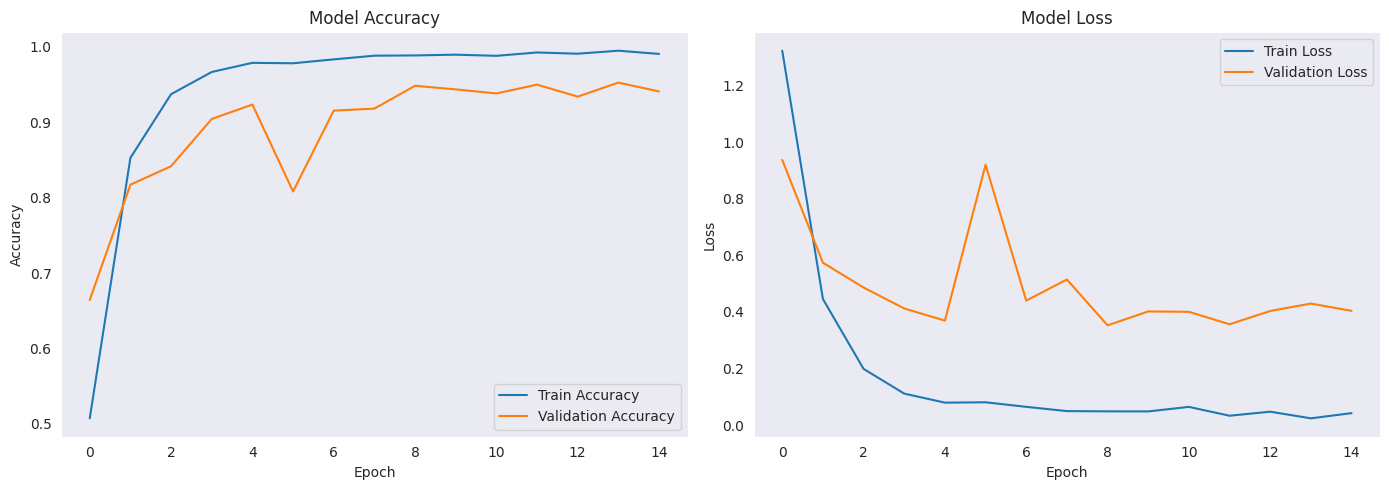

In [ ]:
def plot_training_history(history):

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid()

    plt.tight_layout()
    plt.show()

plot_training_history(history)

209/209 ━━━━━━━━━━━━━━━━━━━━ 17s 75ms/step


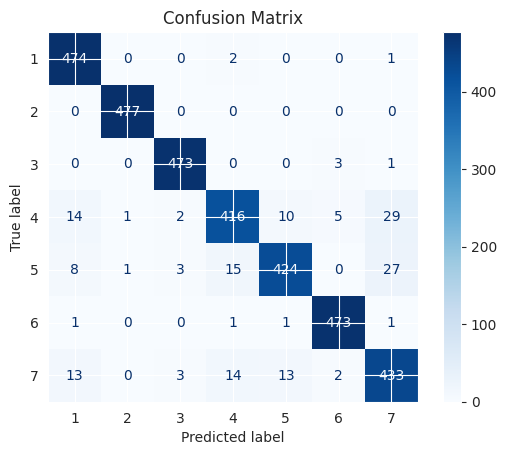

              precision    recall  f1-score   support

           1       0.93      0.99      0.96       477
           2       1.00      1.00      1.00       477
           3       0.98      0.99      0.99       477
           4       0.93      0.87      0.90       477
           5       0.95      0.89      0.92       478
           6       0.98      0.99      0.99       477
           7       0.88      0.91      0.89       478

    accuracy                           0.95      3341
   macro avg       0.95      0.95      0.95      3341
weighted avg       0.95      0.95      0.95      3341



In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# Assuming test_gen_new is already defined as your test data generator
true_labels = test_gen_new.classes
predicted_labels = model.predict(test_gen_new)
predicted_labels = np.argmax(predicted_labels, axis=1)

# Generate confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Get class labels for the axes
class_labels = list(test_gen_new.class_indices.keys())

# Create a heatmap with seaborn
plt.figure(figsize=(10, 8))  # Set the figure size
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels, cbar=True)

# Add title and labels
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Show the plot
plt.show()

# Classification report
report = classification_report(true_labels, predicted_labels, target_names=class_labels)
print(report)
